<div style="background-color:#00843D;padding:22px 28px;border-radius:12px">
  <h2 style="color:white;margin:0;font-size:22px">Analisis Numerico</h2>
  <p style="color:#b8f0c8;margin:6px 0 2px;font-size:14px">Universidad Nacional de Colombia - Sede Manizales</p>
  <p style="color:#b8f0c8;margin:0;font-size:14px">Prof. Carlos Manuel Orrego Franco</p>
</div>

---

# Notebook 07: El Reloj Oculto
## Espacios latentes, verosimilitud y series de tiempo irregulares
### Latent Neural ODEs — Secciones 5 y 6 (Chen et al., NeurIPS 2018)

---

### Objetivos de aprendizaje

Al finalizar este notebook seras capaz de:

1. **Explicar** que es un espacio latente y por que una EDO puede vivir en el
2. **Resolver** numericamente la EDO de rotacion y comparar con la solucion exacta
3. **Implementar** la funcion de log-verosimilitud gaussiana para un modelo latente
4. **Calcular** el estimador de maxima verosimilitud (MLE) de una condicion inicial latente
5. **Distinguir** reconstruccion, interpolacion y extrapolacion desde la trayectoria latente
6. **Discutir** que cambia cuando la dinamica es desconocida y debe aprenderse

---

> Las celdas **[OK]** estan listas: ejecutar con `Shift+Enter`.
> Las celdas **[Ejercicio]** tienen partes por completar marcadas con `# <-- COMPLETAR`.

**Conexion con el paper:** Todo lo que hacemos aqui a mano corresponde a las ecuaciones (11), (12) y (13) de la seccion 5 del paper. La diferencia es que en el paper la dinamica $f$ no es una rotacion conocida: es una red neuronal entrenada.


## 1. La EDO latente: el reloj oculto

Suponemos que detras de una señal observable $x(t)$ hay un **estado oculto** bidimensional
$\mathbf{z}(t) \in \mathbb{R}^2$ que gira en el plano segun la EDO lineal:

$$\frac{d\mathbf{z}}{dt} = A\,\mathbf{z}(t), \qquad A = \begin{pmatrix} 0 & -1 \\ 1 & 0 \end{pmatrix}$$

Esta EDO tiene solucion exacta:

$$\mathbf{z}(t) = \begin{pmatrix} \cos(t + \varphi) \\ \sin(t + \varphi) \end{pmatrix}$$

donde $\varphi$ es la **fase inicial** — la unica variable latente desconocida.
Dado $\varphi$, toda la trayectoria queda determinada.

En el paper (ecuacion 12), este papel lo cumple $z_{t_0}$ y la dinamica $f(\mathbf{z}, \theta_f)$.
Aqui trabajamos con un ejemplo de juguete donde todo es calculable a mano.

| Elemento de este notebook | Ecuacion del paper |
|---------------------------|--------------------|
| $\varphi$ (fase inicial) | $z_{t_0} \sim p(z_{t_0})$ — ec. (11) |
| $A = [[0,-1],[1,0]]$ | $f(\mathbf{z}, \theta_f)$ — dinamica aprendida |
| `solve_ivp(...)` | $\text{ODESolve}(z_{t_0}, f, \theta_f, t_0, \ldots, t_N)$ — ec. (12) |
| $x(t) = z_1(t) + \varepsilon$ | $x_{t_i} \sim p(x \mid z_{t_i}, \theta_x)$ — ec. (13) |


In [12]:
# [OK] Imports y configuracion global

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar, minimize

np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 2.0,
})

VERDE   = "#00843D"
AZUL    = "#1a5fa8"
ROJO    = "#c0392b"
NARANJA = "#e67e22"
MORADO  = "#8e44ad"
GRIS    = "#7f8c8d"

print("Librerias cargadas correctamente.")


Librerias cargadas correctamente.


In [13]:
# [OK] Definir la EDO de rotacion y resolver con solve_ivp
# Compararemos la solucion numerica con la solucion exacta.
# Esto verifica que solve_ivp cumple el papel de ODESolve del paper.

# ── Parametros del sistema ───────────────────────────────────────────────────
PHI_VERDADERA = np.pi / 6          # fase verdadera (desconocida para el estimador)
T_INI, T_FIN  = 0.0, 4 * np.pi    # intervalo de simulacion
SIGMA         = 0.15               # desviacion estandar del ruido del decoder

A_ROT = np.array([[0., -1.],
                   [1.,  0.]])

def dinamica_latente(t, z):
    """dz/dt = A * z  (campo vectorial latente).

    En el paper: f(z, theta_f) -- aqui la conocemos, ahi se aprende.
    """
    return A_ROT @ z

def solucion_exacta(t, phi):
    """z(t) = [cos(t+phi), sin(t+phi)].  Solucion analitica de la EDO."""
    return np.stack([np.cos(t + phi), np.sin(t + phi)], axis=-1)

# ── Resolver numericamente ───────────────────────────────────────────────────
t_denso = np.linspace(T_INI, T_FIN, 600)
z0_real = np.array([np.cos(PHI_VERDADERA), np.sin(PHI_VERDADERA)])

sol = solve_ivp(
    fun=dinamica_latente,
    t_span=(T_INI, T_FIN),
    y0=z0_real,
    t_eval=t_denso,
    method="RK45",
    rtol=1e-8, atol=1e-9,
)

z_num   = sol.y.T                            # (600, 2)
z_exact = solucion_exacta(t_denso, PHI_VERDADERA)  # (600, 2)

print(f"Error maximo solve_ivp vs. solucion exacta: {np.abs(z_num - z_exact).max():.2e}")
print(f"(rtol=1e-8, atol=1e-9  ->  error del orden de la tolerancia pedida)")


Error maximo solve_ivp vs. solucion exacta: 1.92e-08
(rtol=1e-8, atol=1e-9  ->  error del orden de la tolerancia pedida)


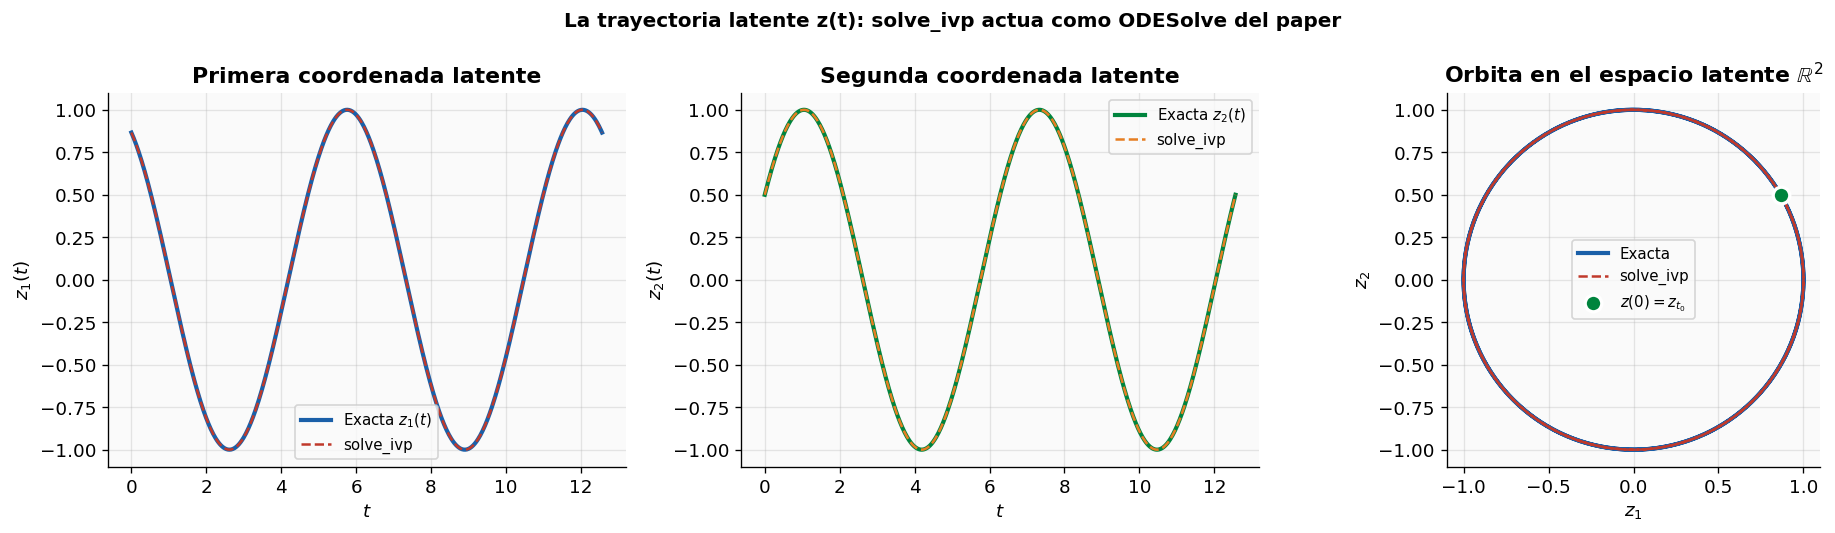

In [14]:
# [OK] Visualizar la trayectoria latente: coordenadas en el tiempo y orbita en R^2

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── Panel 1: z_1(t) ──────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(t_denso, z_exact[:, 0], color=AZUL,  lw=2.5, label=r"Exacta $z_1(t)$")
ax.plot(t_denso, z_num[:, 0],   color=ROJO,  lw=1.5, ls="--", label="solve_ivp")
ax.set_xlabel("$t$"); ax.set_ylabel("$z_1(t)$")
ax.set_title("Primera coordenada latente", fontweight="bold")
ax.legend(fontsize=9)

# ── Panel 2: z_2(t) ──────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(t_denso, z_exact[:, 1], color=VERDE,  lw=2.5, label=r"Exacta $z_2(t)$")
ax.plot(t_denso, z_num[:, 1],   color=NARANJA, lw=1.5, ls="--", label="solve_ivp")
ax.set_xlabel("$t$"); ax.set_ylabel("$z_2(t)$")
ax.set_title("Segunda coordenada latente", fontweight="bold")
ax.legend(fontsize=9)

# ── Panel 3: orbita en R^2 ───────────────────────────────────────────────────
ax = axes[2]
ax.plot(z_exact[:, 0], z_exact[:, 1], color=AZUL, lw=2.5, label="Exacta")
ax.plot(z_num[:, 0],   z_num[:, 1],   color=ROJO, lw=1.5, ls="--", label="solve_ivp")
ax.scatter([z0_real[0]], [z0_real[1]], s=100, color=VERDE, zorder=5,
           edgecolors="white", lw=2, label=r"$z(0) = z_{t_0}$")
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title(r"Orbita en el espacio latente $\mathbb{R}^2$", fontweight="bold")
ax.set_aspect("equal"); ax.legend(fontsize=9)

plt.suptitle(
    "La trayectoria latente z(t): solve_ivp actua como ODESolve del paper",
    fontsize=12, fontweight="bold"
)
plt.tight_layout(); plt.show()


## 2. El decoder y las observaciones ruidosas

No observamos todo el estado latente $\mathbf{z}(t)$. Solo medimos una proyeccion ruidosa
de la primera coordenada (el **decoder**):

$$x(t) = z_1(t) + \varepsilon, \qquad \varepsilon \sim 𝒩(0, \sigma^2)$$

En el paper, el decoder es $x_{t_i} \sim p(x \mid z_{t_i}, \theta_x)$, una red neuronal
que convierte el estado latente en una distribucion sobre observaciones.

**Observaciones en tiempos irregulares:** una ventaja clave de la Latent ODE es que
`ODESolve` puede evaluar $\mathbf{z}(t)$ en cualquier conjunto de tiempos arbitrarios
$t_1, \ldots, t_N$ sin requerir una grilla uniforme. Esto elimina la necesidad de
discretizacion o imputacion que complica a las RNNs clasicas (seccion 5 del paper).


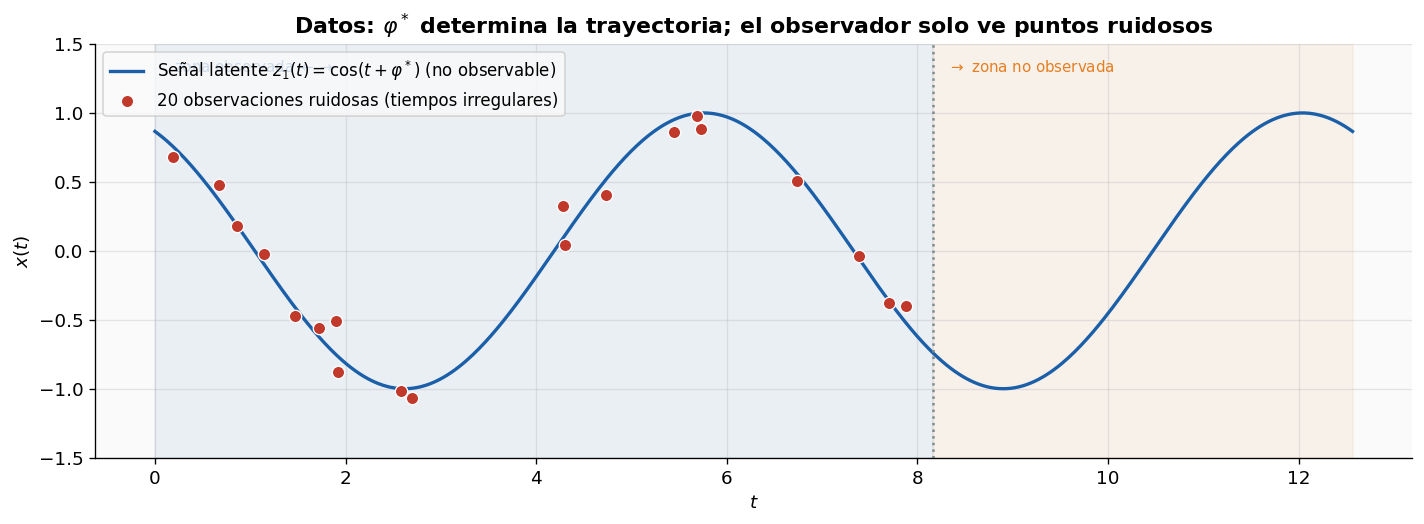

Espaciado entre observaciones: min=0.020, max=1.576, mean=0.405
(si fueran uniformes todos serian iguales)


In [15]:
# [OK] Generar observaciones ruidosas en tiempos irregulares
# El observador solo ve x(t) = z_1(t) + ruido, no z(t) completo.

N_OBS  = 20
T_LIMS = T_FIN * 0.65    # observamos solo hasta el 65% del intervalo total

# Tiempos irregulares: muestreo aleatorio (sin reemplazo) dentro del intervalo
t_obs = np.sort(
    np.random.choice(
        np.linspace(T_INI, T_LIMS, 400), size=N_OBS, replace=False
    )
)

# Decoder: x(t) = cos(t + phi*) + ruido gaussiano
x_obs = np.cos(t_obs + PHI_VERDADERA) + np.random.normal(0, SIGMA, size=N_OBS)

# ── Visualizacion ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.fill_betweenx([-1.5, 1.5], T_INI, T_LIMS,
                  alpha=0.07, color=AZUL, label=None)
ax.fill_betweenx([-1.5, 1.5], T_LIMS, T_FIN,
                  alpha=0.07, color=NARANJA, label=None)

ax.plot(t_denso, np.cos(t_denso + PHI_VERDADERA), color=AZUL, lw=2,
        label=r"Señal latente $z_1(t)=\cos(t+\varphi^*)$ (no observable)")
ax.scatter(t_obs, x_obs, color=ROJO, s=55, zorder=5,
           edgecolors="white", lw=0.8,
           label=f"{N_OBS} observaciones ruidosas (tiempos irregulares)")
ax.axvline(T_LIMS, color=GRIS, lw=1.5, ls=":")
ax.text(T_LIMS + 0.15, 1.30, r"$\rightarrow$ zona no observada",
        fontsize=9, color=NARANJA)
ax.text(0.2, 1.30, r"zona observada $\leftarrow\rightarrow$",
        fontsize=9, color=AZUL)

ax.set_xlabel("$t$"); ax.set_ylabel("$x(t)$")
ax.set_title(
    r"Datos: $\varphi^*$ determina la trayectoria; el observador solo ve puntos ruidosos",
    fontweight="bold"
)
ax.set_ylim(-1.5, 1.5)
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

# Mostrar que los tiempos son realmente irregulares
diffs = np.diff(t_obs)
print(f"Espaciado entre observaciones: min={diffs.min():.3f}, "
      f"max={diffs.max():.3f}, mean={diffs.mean():.3f}")
print("(si fueran uniformes todos serian iguales)")


## 3. La funcion de verosimilitud

Dado un valor candidato $\varphi$, el modelo gaussiano asigna probabilidad a cada observacion:

$$x_i \mid \varphi \sim 𝒩(\cos(t_i + \varphi),\; \sigma^2\bigr)$$

La **log-verosimilitud** conjunta es:

$$\ell(\varphi) = \log p(x_1, \ldots, x_N \mid \varphi) = -\frac{N}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{N}\bigl(x_i - \cos(t_i+\varphi)\bigr)^2$$

Observacion clave: bajo ruido gaussiano con varianza constante,

$$\underbrace{\max_{\varphi}\; \ell(\varphi)}_{\text{MLE}} \iff \underbrace{\min_{\varphi}\; \sum_i (x_i - \cos(t_i+\varphi))^2}_{\text{minimos cuadrados}}$$

Esta equivalencia conecta directamente con los metodos de minimos cuadrados del curso.


In [16]:
# [OK] Definir la log-verosimilitud y su equivalente en SSE

def log_likelihood(phi, t_obs, x_obs, sigma=SIGMA):
    """Log-verosimilitud del modelo gaussiano.

    phi    : float  -- fase inicial candidata (variable latente)
    t_obs  : array  -- tiempos de observacion
    x_obs  : array  -- observaciones ruidosas
    sigma  : float  -- desviacion estandar del ruido

    Conexion con el paper:
        phi        <->  z_{t0}                    (condicion inicial latente)
        cos(t+phi) <->  decoder p(x | z_t, theta_x)
        ell(phi)   <->  log p(x_{t1},...,x_{tN} | z_{t0})
    """
    N = len(t_obs)
    predicciones = np.cos(t_obs + phi)
    sse = np.sum((x_obs - predicciones) ** 2)
    return -N / 2 * np.log(2 * np.pi * sigma**2) - sse / (2 * sigma**2)

def sse(phi, t_obs, x_obs):
    """Suma de errores cuadrados -- se minimiza para encontrar el MLE."""
    return np.sum((x_obs - np.cos(t_obs + phi)) ** 2)

# Calcular la likelihood para los dos valores de la guia
phi_A, phi_B = 0.0, np.pi / 2
ll_A  = log_likelihood(phi_A, t_obs, x_obs)
ll_B  = log_likelihood(phi_B, t_obs, x_obs)
sse_A = sse(phi_A, t_obs, x_obs)
sse_B = sse(phi_B, t_obs, x_obs)

print(f"Hipotesis A: phi = 0       ->  log-lik = {ll_A:8.2f},  SSE = {sse_A:.4f}")
print(f"Hipotesis B: phi = pi/2   ->  log-lik = {ll_B:8.2f},  SSE = {sse_B:.4f}")
print()
print(f"La hipotesis con MAYOR log-lik y MENOR SSE es: ",
      f"phi = 0" if ll_A > ll_B else f"phi = pi/2")


Hipotesis A: phi = 0       ->  log-lik =   -52.44,  SSE = 3.2402
Hipotesis B: phi = pi/2   ->  log-lik =  -181.81,  SSE = 9.0616

La hipotesis con MAYOR log-lik y MENOR SSE es:  phi = 0


In [17]:
# [Ejercicio 1] Calcular la likelihood a mano para los tres puntos de la guia
#
# La guia usa: t1=0, t2=pi/2, t3=pi y observaciones x1=0.9, x2=0.1, x3=-1.1
# Verifique aqui los calculos que hizo en papel.

t_guia = np.array([0.0, np.pi/2, np.pi])
x_guia = np.array([0.9, 0.1, -1.1])

# ── Hipotesis A: phi = 0 ─────────────────────────────────────────────────────
phi_ej_A = 0.0

# Predicciones del modelo: cos(t_i + phi)
pred_A = np.cos(t_guia + phi_ej_A)  # <-- COMPLETAR: calcule cos(t_guia + phi_ej_A)

# Errores: x_i - prediccion_i
err_A = x_guia - pred_A   # <-- COMPLETAR

# Suma de cuadrados
sse_ej_A = np.sum(err_A**2)  # <-- COMPLETAR: np.sum(err_A ** 2)

# ── Hipotesis B: phi = pi/2 ──────────────────────────────────────────────────
phi_ej_B = np.pi / 2

pred_B   = np.cos(t_guia + phi_ej_B)  # <-- COMPLETAR
err_B    = x_guia - pred_B  # <-- COMPLETAR
sse_ej_B = np.sum(err_B**2)  # <-- COMPLETAR

# ── Comparar (descomentar cuando complete) ───────────────────────────────────
print("Hipotesis A (phi=0):")
print(f"  Predicciones: {np.round(pred_A, 4)}")
print(f"  Errores:      {np.round(err_A,  4)}")
print(f"  SSE:          {sse_ej_A:.4f}  (la guia dice 0.03)")
print()
print("Hipotesis B (phi=pi/2):")
print(f"  Predicciones: {np.round(pred_B, 4)}")
print(f"  Errores:      {np.round(err_B,  4)}")
print(f"  SSE:          {sse_ej_B:.4f}  (la guia dice 3.23)")
print()
print(f"Mayor likelihood -> phi = {'0' if sse_ej_A < sse_ej_B else 'pi/2'}")

# ================================================
# Preguntas de reflexion:
# 1. Los valores de SSE de la guia (0.03 y 3.23) usan solo 3 puntos.
#    Con N=20 observaciones de ruido real, ¿esperaria SSE mayor o menor?
# 2. Si sigma fuera 10 veces mayor, ¿cambia el phi que maximiza la likelihood?
#    ¿Cambia el valor numerico de la likelihood? ¿Por que?
# ================================================


Hipotesis A (phi=0):
  Predicciones: [ 1.  0. -1.]
  Errores:      [-0.1  0.1 -0.1]
  SSE:          0.0300  (la guia dice 0.03)

Hipotesis B (phi=pi/2):
  Predicciones: [ 0. -1. -0.]
  Errores:      [ 0.9  1.1 -1.1]
  SSE:          3.2300  (la guia dice 3.23)

Mayor likelihood -> phi = 0


## 4. El paisaje de verosimilitud y el MLE

El **estimador de maxima verosimilitud** (MLE) es el valor de $\varphi$ que maximiza
$\ell(\varphi)$:

$$\hat{\varphi} = \arg\max_{\varphi \in [-\pi, \pi]} \ell(\varphi)
                = \arg\min_{\varphi \in [-\pi, \pi]} \sum_{i=1}^{N} (x_i - \cos(t_i+\varphi))^2$$

En el paper, el MLE se reemplaza por la maximizacion de la **ELBO** (cota variacional
inferior) usando backpropagation con el metodo adjunto del NB06.
Aqui usamos busqueda directa en la grilla y el metodo de Brent, que son exactos
para este problema de un parametro.


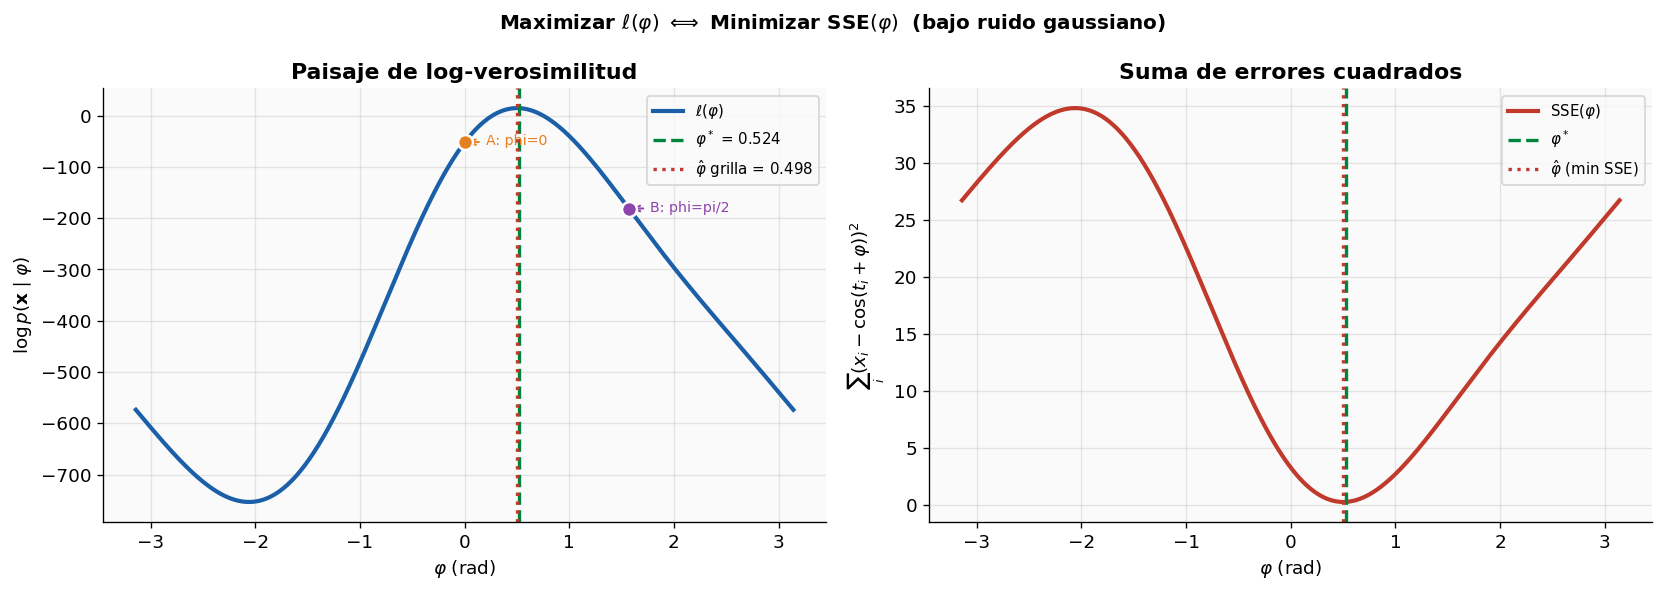

In [18]:
# [OK] Paisaje de verosimilitud: barrer phi en [-pi, pi]

phi_grilla = np.linspace(-np.pi, np.pi, 600)
ll_grilla  = np.array([log_likelihood(phi, t_obs, x_obs) for phi in phi_grilla])
sse_grilla = np.array([sse(phi, t_obs, x_obs)            for phi in phi_grilla])

# MLE por grilla (referencia)
phi_mle_grilla = phi_grilla[np.argmax(ll_grilla)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel izquierdo: log-likelihood ──────────────────────────────────────────
ax = axes[0]
ax.plot(phi_grilla, ll_grilla, color=AZUL, lw=2.5, label=r"$\ell(\varphi)$")
ax.axvline(PHI_VERDADERA,   color=VERDE, lw=2, ls="--",
           label=rf"$\varphi^*$ = {PHI_VERDADERA:.3f}")
ax.axvline(phi_mle_grilla,  color=ROJO,  lw=2, ls=":",
           label=rf"$\hat{{\varphi}}$ grilla = {phi_mle_grilla:.3f}")

# Marcar las dos hipotesis de la guia
for phi_h, lbl, col in [(0.0, "A: phi=0", NARANJA), (np.pi/2, "B: phi=pi/2", MORADO)]:
    ll_h = log_likelihood(phi_h, t_obs, x_obs)
    ax.scatter([phi_h], [ll_h], s=80, color=col, zorder=5, edgecolors="white", lw=1.5)
    ax.annotate(lbl, xy=(phi_h, ll_h), xytext=(phi_h+0.2, ll_h-5),
                fontsize=8.5, color=col,
                arrowprops=dict(arrowstyle="->", color=col, lw=1.2))

ax.set_xlabel(r"$\varphi$ (rad)"); ax.set_ylabel(r"$\log p(\mathbf{x} \mid \varphi)$")
ax.set_title("Paisaje de log-verosimilitud", fontweight="bold")
ax.legend(fontsize=9)

# ── Panel derecho: SSE ───────────────────────────────────────────────────────
ax = axes[1]
ax.plot(phi_grilla, sse_grilla, color=ROJO, lw=2.5, label=r"SSE$(\varphi)$")
ax.axvline(PHI_VERDADERA,  color=VERDE, lw=2, ls="--", label=r"$\varphi^*$")
ax.axvline(phi_mle_grilla, color=ROJO,  lw=2, ls=":",  label=r"$\hat{\varphi}$ (min SSE)")
ax.set_xlabel(r"$\varphi$ (rad)")
ax.set_ylabel(r"$\sum_i (x_i - \cos(t_i+\varphi))^2$")
ax.set_title("Suma de errores cuadrados", fontweight="bold")
ax.legend(fontsize=9)

plt.suptitle(
    r"Maximizar $\ell(\varphi)$ $\Longleftrightarrow$ Minimizar SSE$(\varphi)$  (bajo ruido gaussiano)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout(); plt.show()


In [19]:
# [Ejercicio 2] Encontrar el MLE con el metodo de Brent y comparar con la grilla
#
# scipy.optimize.minimize_scalar con method="bounded" implementa el metodo de Brent:
# una combinacion de biseccion y parabolica que converge supralinealmente.

# ── MLE con Brent ────────────────────────────────────────────────────────────
resultado_brent = minimize_scalar(
    fun=lambda phi: sse(phi, t_obs, x_obs),
    bounds=(-np.pi, np.pi),
    method="bounded"
)

phi_mle_brent = resultado_brent.x    # <-- COMPLETAR: resultado_brent.x

# ── Reporte ──────────────────────────────────────────────────────────────────
# Descomentar cuando complete:
print("=" * 55)
print("  Estimacion de la fase inicial latente")
print("=" * 55)
print(f"  Fase verdadera  phi*        = {PHI_VERDADERA:.4f} rad ({np.degrees(PHI_VERDADERA):.1f} deg)")
print(f"  MLE (grilla)    phi_grilla  = {phi_mle_grilla:.4f} rad")
print(f"  MLE (Brent)     phi_brent   = {phi_mle_brent:.4f} rad")
print()
print(f"  Error grilla : {abs(phi_mle_grilla - PHI_VERDADERA):.4f} rad")
print(f"  Error Brent  : {abs(phi_mle_brent  - PHI_VERDADERA):.4f} rad")
print("=" * 55)

# ================================================
# Preguntas de reflexion:
# 1. ¿Por que el error de Brent es generalmente menor que el de la grilla?
# 2. Si tuvieramos phi en R^d con d=4 (como en el paper, dim. latente = 4),
#    ¿el metodo de Brent seguiria funcionando directamente? ¿Que usariamos?
# 3. El paper usa el metodo adjunto (NB06) en lugar de Brent.
#    ¿Que ventaja tiene cuando los parametros son miles de pesos de una red?
# ================================================


  Estimacion de la fase inicial latente
  Fase verdadera  phi*        = 0.5236 rad (30.0 deg)
  MLE (grilla)    phi_grilla  = 0.4982 rad
  MLE (Brent)     phi_brent   = 0.5021 rad

  Error grilla : 0.0253 rad
  Error Brent  : 0.0215 rad


## 5. Reconstruccion, interpolacion y extrapolacion

Una vez estimado $\hat{\varphi}$, tenemos una condicion inicial latente $z_{t_0}^{\hat{}} = (\cos\hat{\varphi},\, \sin\hat{\varphi})$.
Desdde ese punto, `ODESolve` puede producir la trayectoria latente en **cualquier tiempo**:

- **Reconstruccion:** estimar $z_{t_i}$ en tiempos ya observados.
- **Interpolacion:** estimar en tiempos entre observaciones, dentro del intervalo $[t_0, t_N]$.
- **Extrapolacion:** predecir en tiempos **mas alla de** $t_N$ — sin haber visto esos datos.

En el paper (figura 8), la Latent ODE supera a la RNN en extrapolacion precisamente
porque la trayectoria latente es continua y sigue una dinamica globalmente coherente.


Error medio de reconstruccion (interpolacion): 0.0174
Error medio de extrapolacion               : 0.0138

Nota: el error de extrapolacion crece con la distancia a los datos observados.
En el paper (fig. 8), la Latent ODE mantiene este error bajo mucho mas tiempo
que la RNN, porque la EDO preserva la estructura global de la dinamica.


<>:49: SyntaxWarning: invalid escape sequence '\h'
<>:49: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_3293/222121690.py:49: SyntaxWarning: invalid escape sequence '\h'
  ax.set_xlabel("$t$"); ax.set_ylabel("$|\hat{x}(t) - x^*(t)|$")


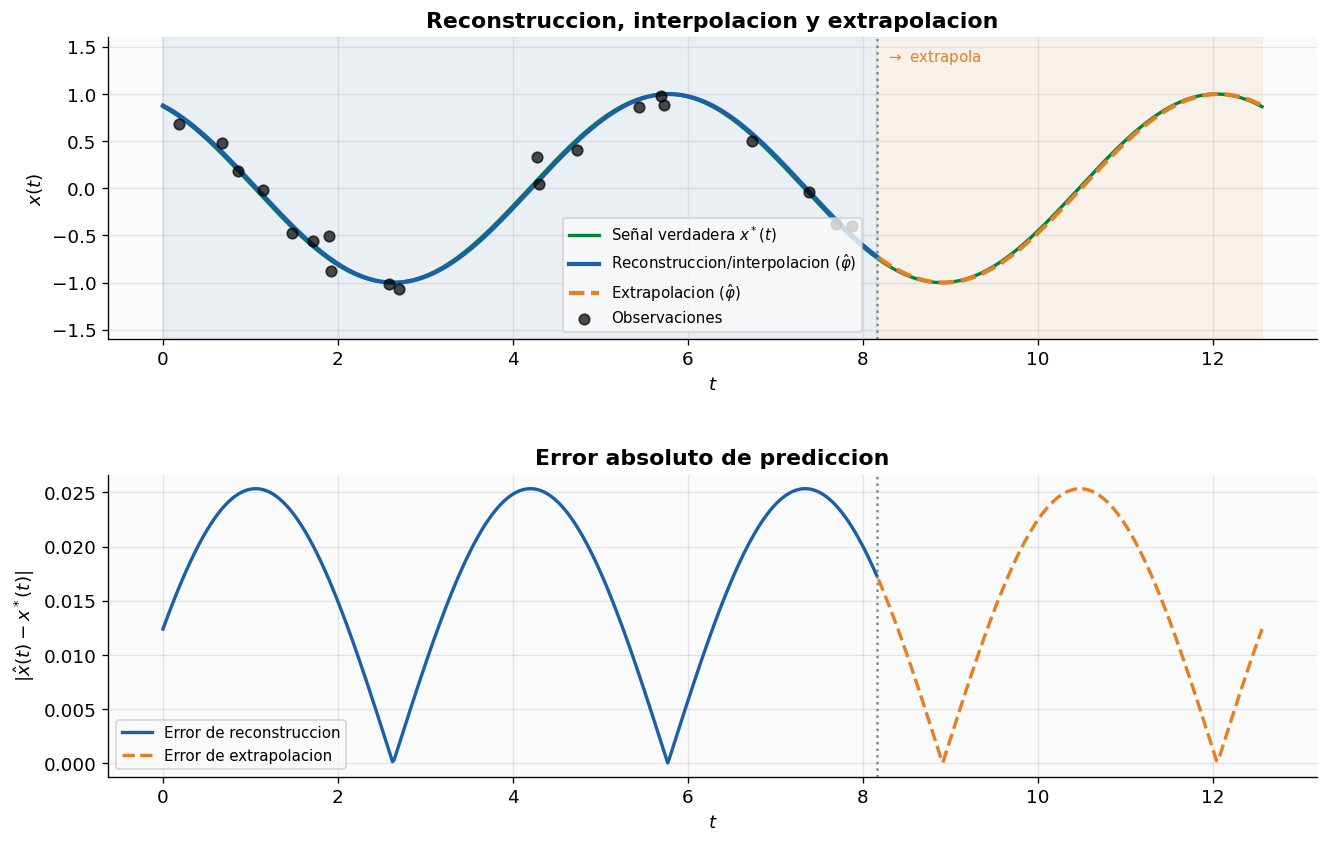

In [20]:
# [OK] Reconstruccion, interpolacion y extrapolacion desde phi_mle_grilla
# (Sustituir por phi_mle_brent cuando complete el Ejercicio 2)

phi_hat = phi_mle_grilla    # <- cambiar a phi_mle_brent al terminar Ej. 2

T_EXTRAP = T_FIN
t_full   = np.linspace(T_INI, T_EXTRAP, 700)

# ODESolve desde la condicion inicial estimada
z0_hat = np.array([np.cos(phi_hat), np.sin(phi_hat)])
sol_hat = solve_ivp(
    fun=dinamica_latente,
    t_span=(T_INI, T_EXTRAP),
    y0=z0_hat,
    t_eval=t_full,
    method="RK45", rtol=1e-8, atol=1e-9,
)
x_hat  = sol_hat.y[0, :]                   # decoder: x(t) = z_1(t)
x_true = np.cos(t_full + PHI_VERDADERA)    # señal verdadera (normalmente desconocida)

mask_obs    = t_full <= T_LIMS
mask_extrap = t_full >  T_LIMS

# ── Figura ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                          gridspec_kw={"hspace": 0.45})

# Panel superior: señal completa
ax = axes[0]
ax.fill_betweenx([-1.6, 1.6], T_INI,  T_LIMS,  alpha=0.07, color=AZUL)
ax.fill_betweenx([-1.6, 1.6], T_LIMS, T_EXTRAP, alpha=0.07, color=NARANJA)
ax.plot(t_full, x_true,                    color=VERDE, lw=2,   label=r"Señal verdadera $x^*(t)$")
ax.plot(t_full[mask_obs], x_hat[mask_obs], color=AZUL,  lw=2.5, label=r"Reconstruccion/interpolacion ($\hat{\varphi}$)")
ax.plot(t_full[mask_extrap], x_hat[mask_extrap], color=NARANJA, lw=2.5,
        ls="--", label=r"Extrapolacion ($\hat{\varphi}$)")
ax.scatter(t_obs, x_obs, color="k", s=40, zorder=5, alpha=0.7, label="Observaciones")
ax.axvline(T_LIMS, color=GRIS, lw=1.5, ls=":")
ax.text(T_LIMS+0.1, 1.35, r"$\rightarrow$ extrapola", fontsize=9, color=NARANJA)
ax.set_xlabel("$t$"); ax.set_ylabel("$x(t)$")
ax.set_title("Reconstruccion, interpolacion y extrapolacion", fontweight="bold")
ax.set_ylim(-1.6, 1.6); ax.legend(fontsize=9)

# Panel inferior: error punto a punto
ax = axes[1]
error = np.abs(x_hat - x_true)
ax.plot(t_full[mask_obs],    error[mask_obs],    color=AZUL,   lw=2, label="Error de reconstruccion")
ax.plot(t_full[mask_extrap], error[mask_extrap], color=NARANJA, lw=2, ls="--", label="Error de extrapolacion")
ax.axvline(T_LIMS, color=GRIS, lw=1.5, ls=":")
ax.set_xlabel("$t$"); ax.set_ylabel("$|\hat{x}(t) - x^*(t)|$")
ax.set_title("Error absoluto de prediccion", fontweight="bold")
ax.legend(fontsize=9)

err_recon  = error[mask_obs].mean()
err_extrap = error[mask_extrap].mean()
print(f"Error medio de reconstruccion (interpolacion): {err_recon:.4f}")
print(f"Error medio de extrapolacion               : {err_extrap:.4f}")
print()
print("Nota: el error de extrapolacion crece con la distancia a los datos observados.")
print("En el paper (fig. 8), la Latent ODE mantiene este error bajo mucho mas tiempo")
print("que la RNN, porque la EDO preserva la estructura global de la dinamica.")
plt.show()


## 6. ¿Que pasa cuando la dinamica es desconocida?

Hasta aqui conocemos $A$ y solo estimamos $\varphi$. Pero en el paper **ninguna** de las dos cosas es conocida:

- La condicion inicial $z_{t_0}$ se infiere desde los datos mediante una **recognition network** (encoder).
- La dinamica $f(\mathbf{z}, \theta_f)$ es una **red neuronal** que se entrena.

En este bloque estimamos conjuntamente $\varphi$ y los coeficientes de $A$ directamente desde los datos.
Esto motiva la pregunta central del paper: si con 3 parametros ya hay incertidumbre,
¿que ocurre con cientos o miles de pesos de una red?

**Advertencia numerica:** el paisaje de likelihood conjunto puede tener multiples minimos locales.
El optimizador puede converger a una solucion diferente a la verdadera incluso con datos suficientes.
Esto ilustra la seccion 6 del paper: la unicidad de Picard-Lindelof garantiza
unicidad de la **trayectoria** dada la condicion inicial, pero no la unicidad del
**problema de estimacion** de los parametros.


In [21]:
# [OK] Definir la log-likelihood para estimacion conjunta de (phi, a12, a21)
# Estructura de A: [[0, a12], [a21, 0]]  (se puede generalizar a cualquier matriz)

def resolver_con_A(phi, a12, a21, t_eval):
    """Integra dz/dt = A(a12,a21)*z desde z0=(cos phi, sin phi)."""
    A_p = np.array([[0., a12], [a21, 0.]])
    z0  = np.array([np.cos(phi), np.sin(phi)])
    sol = solve_ivp(
        fun=lambda t, z: A_p @ z,
        t_span=(t_eval[0], t_eval[-1]),
        y0=z0,
        t_eval=t_eval,
        method="RK45", rtol=1e-6, atol=1e-7,
    )
    return sol.y[0, :] if sol.success else np.full(len(t_eval), np.nan)

def neg_ll_conjunta(params, t_obs, x_obs, sigma=SIGMA):
    """Negativa de la log-likelihood para params = [phi, a12, a21]."""
    phi, a12, a21 = params
    x_pred = resolver_con_A(phi, a12, a21, t_obs)
    if np.any(np.isnan(x_pred)):
        return 1e10
    return np.sum((x_obs - x_pred) ** 2) / (2 * sigma**2)

# Verificacion
# Con la dinamica verdadera (phi=PHI_VERDADERA, a12=-1, a21=1), el error debe ser bajo
nll_verdad = neg_ll_conjunta([PHI_VERDADERA, -1.0, 1.0], t_obs, x_obs)
print(f"Neg-LL en los valores verdaderos (phi*, a12=-1, a21=1): {nll_verdad:.4f}")
print("(debe ser el valor mas bajo posible dado el ruido)")


Neg-LL en los valores verdaderos (phi*, a12=-1, a21=1): 11.8486
(debe ser el valor mas bajo posible dado el ruido)


  Estimacion conjunta: phi, a12, a21
  phi : verdad = +0.5236  |  estimado = +0.7417  |  error = 0.2181
  a12 : verdad = -1.0000  |  estimado = -0.8957  |  error = 0.1043
  a21 : verdad = +1.0000  |  estimado = +1.1227  |  error = 0.1227


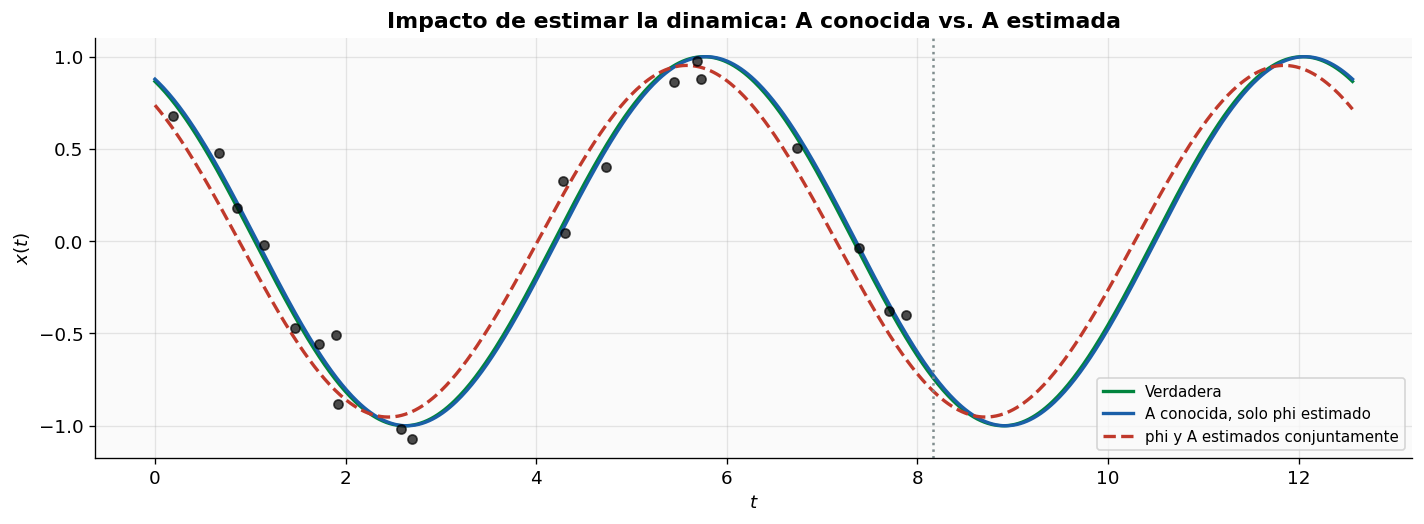

In [22]:
# [Ejercicio 3] Estimar conjuntamente phi, a12 y a21 con Nelder-Mead
#
# Nelder-Mead es un metodo de optimizacion sin gradiente (simplex).
# Es adecuado aqui porque neg_ll_conjunta no es diferenciable con respecto
# a los parametros del solver. En el paper, el metodo adjunto (NB06)
# proporciona gradientes exactos para optimizar con Adam o SGD.

# Punto de partida: lejos de la solucion verdadera
theta0 = np.array([0.0, -0.7, 0.7])   # verdad: [pi/6, -1.0, 1.0]

# ── Optimizacion ─────────────────────────────────────────────────────────────
resultado_conjunto = minimize(
    fun=neg_ll_conjunta,
    x0=theta0,
    args=(t_obs, x_obs),
    method="Nelder-Mead",
    options={"maxiter": 5000, "xatol": 1e-5, "fatol": 1e-5}
)

# Descomentar cuando complete:
phi_est, a12_est, a21_est = resultado_conjunto.x

print("=" * 60)
print("  Estimacion conjunta: phi, a12, a21")
print("=" * 60)
tabla = [
    ("phi",  PHI_VERDADERA, phi_est),
    ("a12",  -1.0,          a12_est),
    ("a21",   1.0,          a21_est),
]
for nombre, verdad, estimado in tabla:
    error = abs(estimado - verdad)
    print(f"  {nombre:4s}: verdad = {verdad:+.4f}  |  estimado = {estimado:+.4f}  |  error = {error:.4f}")
print("=" * 60)

# Reconstruir con los parametros aprendidos
x_conjunto = resolver_con_A(phi_est, a12_est, a21_est, t_full)
x_solo_phi = x_hat   # del Ejercicio 2

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(t_full, x_true,      color=VERDE,   lw=2, label="Verdadera")
ax.plot(t_full, x_solo_phi,  color=AZUL,    lw=2, label="A conocida, solo phi estimado")
ax.plot(t_full, x_conjunto,  color=ROJO,    lw=2, ls="--", label="phi y A estimados conjuntamente")
ax.scatter(t_obs, x_obs, color="k", s=30, zorder=5, alpha=0.7)
ax.axvline(T_LIMS, color=GRIS, lw=1.5, ls=":")
ax.set_xlabel("$t$"); ax.set_ylabel("$x(t)$")
ax.set_title("Impacto de estimar la dinamica: A conocida vs. A estimada", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# ================================================
# Preguntas de reflexion:
# ==============================================================================

# 1. ¿Por qué el error de phi es mayor cuando A también se estima?
# R/ Por un problema de no-identificabilidad. Si A es fija, el paisaje de likelihood
# tiene un pico claro para buscar phi. Pero si estimamos ambos a la vez, el modelo
# puede "compensar" cambios en phi moviendo los valores de A. El paisaje se deforma
# en un valle plano (vaguada), donde infinitas combinaciones de (phi, A) generan
# casi la misma trayectoria. Al no haber un óptimo único, la varianza y el error se disparan.

# 2. ¿Qué estrategias usa el paper para que el entrenamiento con ~800 parámetros funcione?
# R/ Aplica Inferencia Variacional Amortizada con tres pilares:
# - Recognition Network: En lugar de optimizar parámetros para cada serie temporal por separado,
#   entrena un solo encoder que predice los parámetros latentes de golpe. El esfuerzo se "amortiza".
# - ELBO: Maximiza esta cota que incluye un término de divergencia KL. Esto actúa como un
#   regularizador natural que evita que los 800 parámetros memoricen el ruido (evita overfitting).
# - Minibatching: Usa muestras pequeñas con SGD. Acelera el cómputo y el ruido estocástico del
#   muestreo ayuda a que el optimizador no se quede atrapado en los mínimos locales del paisaje.

# 3. Picard-Lindelöf garantiza unicidad de la trayectoria dados los parámetros.
#    ¿Garantiza la unicidad de los parámetros dados los datos?
# R/ No, en absoluto. Picard-Lindelöf resuelve el "problema directo" (parámetros -> una trayectoria única).
# Pero encontrar los parámetros desde los datos es un "problema inverso". El teorema no funciona al revés:
# sistemas con leyes y parámetros completamente distintos pueden terminar produciendo trayectorias
# visualmente idénticas, especialmente si los datos tienen ruido o están incompletos.

## 7. Resumen: el reloj oculto y el paper

### Lo que construimos

| Concepto | Clave |
|----------|-------|
| **Espacio latente** | $\mathbf{z}(t)\in\mathbb{R}^2$ no se observa; solo $x(t)=z_1(t)+\varepsilon$ |
| **Variable latente** | $\varphi$ determina toda la trayectoria; analogo a $z_{t_0}$ del paper |
| **ODESolve** | `solve_ivp` integra la dinamica y evalua en tiempos arbitrarios |
| **Log-likelihood** | Mide compatibilidad de una hipotesis con los datos, no "verdad" |
| **MLE** | Maximizar $\ell(\varphi)$ equivale a minimizar SSE bajo ruido gaussiano |
| **Interpolacion** | ODESolve evalua la trayectoria dentro del intervalo observado |
| **Extrapolacion** | ODESolve predice fuera del intervalo; funciona si la dinamica es correcta |
| **Dinamica desconocida** | Estimar $A$ junto con $\varphi$ introduce mayor incertidumbre |

---

### La correspondencia completa con el paper

| Este notebook | Paper — Seccion 5 | Ecuacion |
|---------------|-------------------|----------|
| $\varphi$ | $z_{t_0} \sim p(z_{t_0})$ | (11) |
| $A = [[0,-1],[1,0]]$ | $f(\mathbf{z}, \theta_f)$ — red neuronal | — |
| `solve_ivp(z0, A, t_obs)` | $\text{ODESolve}(z_{t_0}, f, \theta_f, t_0,\ldots,t_N)$ | (12) |
| $x(t) = z_1(t)+\varepsilon$ | $x_{t_i} \sim p(x\mid z_{t_i}, \theta_x)$ | (13) |
| Minimizar SSE (Brent) | Maximizar ELBO (metodo adjunto) | NB06 |
| Tiempos $t_1,\ldots,t_N$ irregulares | Tiempos arbitrarios en `ODESolve` | — |
| Paisaje de likelihood 1D | Paisaje de likelihood en $\mathbb{R}^d$ con gradientes | — |

---

### El recorrido completo de la serie

```
NB01: Neurona biologica -> FitzHugh-Nagumo -> RK4 -> Diagrama de fases
NB02: McCulloch-Pitts -> Perceptron -> Limites del modelo lineal
NB03: Gradiente -> Backpropagation -> Keras -> Flatten/Padding
NB04: MNIST -> 97%+ exactitud -> Lo que aprende la primera capa
NB05: ResNet=Euler -> RK-Net=RK4 -> Tabla 1 del paper
NB06: Estado adjunto -> Dinamicas aumentadas -> Neural ODE real
NB07: Espacio latente -> Likelihood -> Reloj oculto -> Seccion 5 del paper
```

---

**Pregunta abierta para el seminario:**

En el Ejercicio 3 estimamos $A$ con 3 parametros. En el paper, $f$ es una red con ~800.
Si dos condiciones iniciales distintas producen reconstrucciones parecidas en el intervalo observado,
¿como sabe el modelo cual representacion latente es "correcta"?
¿Que papel cumple la ELBO (vs. la likelihood pura) para mitigar este problema?

---

*Analisis Numerico  |  Universidad Nacional de Colombia  |  Prof. Carlos Manuel Orrego Franco*
